In [24]:
# DECODELABS 2ND PROJECT 
# Analyzing the Cleaned dataset 
# Goals of analyzes
 
#Steps:
#  1. Load the data and inspect its structure
#  2. Calculate basic statistics (mean, median, count, etc.)
#  3. Identify trends over time
#  4. Identify outliers
#  5. Summarize key observations

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel(r"C:\Users\user\Documents\data analytics daily challenge\Decodelabs\Cleaned_Dataset.xlsx")

NUMERIC_COLS = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
CATEGORICAL_COLS = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]


In [26]:
def load_and_inspect(path):
    df = pd.read_excel(path)
 
    print("Shape:", df.shape)
    print("\nColumn types:")
    print(df.dtypes)
 
    print("\nMissing values per column:")
    print(df.isna().sum())
 
    print("\nDate range:", df["Date"].min(), "to", df["Date"].max())
 
    return df

In [27]:
def basic_statistics(df):
    print("\n=== Basic statistics (numeric columns) ===")
    stats = df[NUMERIC_COLS].agg(["mean", "median", "std", "min", "max", "count"]).T
    print(stats)

    print("\n=== Category counts (categorical columns) ===")
    for col in CATEGORICAL_COLS:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))

    return stats
    print("\n=== Category counts (categorical columns) ===")
    for col in CATEGORICAL_COLS:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False))


In [34]:
  def analyze_trends(df):
    df = df.copy()
    df["YearMonth"] = df["Date"].dt.to_period("M")
    df["Year"] = df["Date"].dt.year
 
    print("\n=== Monthly orders and revenue ===")
    monthly = df.groupby("YearMonth").agg(
        orders=("OrderID", "count"),
        revenue=("TotalPrice", "sum")
    ).reset_index()
    print(monthly.to_string(index=False))
 
    print("\n=== Yearly totals ===")
    yearly = df.groupby("Year").agg(
        orders=("OrderID", "count"),
        revenue=("TotalPrice", "sum")
    )
    print(yearly)
 
    print("\n=== Average order value by product ===")
    print(df.groupby("Product")["TotalPrice"].agg(["mean", "median", "count"])
            .sort_values("mean", ascending=False))
 
    print("\n=== Average order value by order status ===")
    print(df.groupby("OrderStatus")["TotalPrice"].agg(["mean", "count"]))
 
    print("\n=== Average order value by referral source ===")
    print(df.groupby("ReferralSource")["TotalPrice"].agg(["mean", "count"]))
 
    return monthly, yearly
 
    def analyze_trends(df):
        df = df.copy()
        df["YearMonth"] = df["Date"].dt.to_period("M")
        df["Year"] = df["Date"].dt.year

        print("\n=== Monthly orders and revenue ===")
        monthly = df.groupby("YearMonth").agg(
            orders=("OrderID", "count"),
            revenue=("TotalPrice", "sum")
        ).reset_index()
        print(monthly.to_string(index=False))

        print("\n=== Yearly totals ===")
        yearly = df.groupby("Year").agg(
            orders=("OrderID", "count"),
            revenue=("TotalPrice", "sum")
        )
        print(yearly)

        print("\n=== Average order value by product ===")
        print(df.groupby("Product")["TotalPrice"].agg(["mean", "median", "count"])
                .sort_values("mean", ascending=False))

        print("\n=== Average order value by order status ===")
        print(df.groupby("OrderStatus")["TotalPrice"].agg(["mean", "count"]))

        print("\n=== Average order value by referral source ===")
        print(df.groupby("ReferralSource")["TotalPrice"].agg(["mean", "count"]))

        return monthly, yearly

    def plot_trends(df, monthly):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # --- Chart 1: Monthly revenue trend (line chart) ---
        ax = axes[0, 0]
        ax.plot(monthly["YearMonth"].astype(str), monthly["revenue"], marker="o", color="#2a78d6")
        ax.set_title("Monthly Revenue Trend")
        ax.set_xlabel("Month")
        ax.set_ylabel("Revenue ($)")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

        # --- Chart 2: Monthly order count trend (line chart) ---
        ax = axes[0, 1]
        ax.plot(monthly["YearMonth"].astype(str), monthly["orders"], marker="o", color="#eb6834")
        ax.set_title("Monthly Order Count Trend")
        ax.set_xlabel("Month")
        ax.set_ylabel("Number of Orders")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(alpha=0.3)

        # --- Chart 3: Average order value by product (bar chart) ---
        ax = axes[1, 0]
        by_product = df.groupby("Product")["TotalPrice"].mean().sort_values()
        ax.barh(by_product.index, by_product.values, color="#2a78d6")
        ax.set_title("Average Order Value by Product")
        ax.set_xlabel("Average Total Price ($)")

        # --- Chart 4: TotalPrice distribution with outlier boundary (histogram) ---
        ax = axes[1, 1]
        q1, q3 = df["TotalPrice"].quantile(0.25), df["TotalPrice"].quantile(0.75)
        high_bound = q3 + 1.5 * (q3 - q1)
        ax.hist(df["TotalPrice"], bins=30, color="#2a78d6", edgecolor="white")
        ax.axvline(high_bound, color="red", linestyle="--", label=f"Outlier threshold (${high_bound:,.0f})")
        ax.set_title("Distribution of Total Price (with Outlier Threshold)")
        ax.set_xlabel("Total Price ($)")
        ax.set_ylabel("Number of Orders")
        ax.legend()

        fig.tight_layout()
        fig.savefig("dataset_trends.png", dpi=150)
        print("Saved combined chart to: dataset_trends.png")
        plt.show()
    fig.savefig("dataset_trends.png", dpi=150)
    print("Saved combined chart to: dataset_trends.png")
    plt.show()
plt.show()

In [29]:
def detect_outliers(df, columns=NUMERIC_COLS):
    print("\n=== Outlier detection (IQR method) ===")
    outlier_summary = {}
 
    for col in columns:
        s = df[col]
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
 
        outliers = df[(s < low) | (s > high)]
        outlier_summary[col] = outliers
 
        print(f"{col}: bounds=({low:.2f}, {high:.2f})  n_outliers={len(outliers)}")
 
    # Show the actual outlier rows for TotalPrice (the column with hits)
    if len(outlier_summary.get("TotalPrice", [])) > 0:
        print("\nTotalPrice outlier rows:")
        print(outlier_summary["TotalPrice"][
            ["OrderID", "Product", "Quantity", "UnitPrice", "TotalPrice"]
        ].to_string(index=False))
 
    return outlier_summary

In [30]:
def summarize_observations(df, stats, monthly, yearly, outlier_summary):
    print("\n=== Summary of key observations ===")
 
    mean_tp = stats.loc["TotalPrice", "mean"]
    median_tp = stats.loc["TotalPrice", "median"]
    skew_note = "right-skewed (mean > median)" if mean_tp > median_tp else "left-skewed or symmetric"
 
    print(f"1. TotalPrice distribution is {skew_note}: "
          f"mean=${mean_tp:.2f}, median=${median_tp:.2f}.")
 
    print(f"2. {sum(len(v) for v in outlier_summary.values())} total outlier rows detected "
          f"across numeric columns (IQR method).")
 
    first_year, last_year = yearly.index.min(), yearly.index.max()
    print(f"3. Revenue by year: "
          + ", ".join(f"{y}=${r:,.2f}" for y, r in yearly['revenue'].items()))
 
    top_product = df.groupby("Product")["TotalPrice"].mean().idxmax()
    print(f"4. Highest average order value by product: {top_product}.")
 
    top_status = df.groupby("OrderStatus")["TotalPrice"].mean().idxmax()
    print(f"5. Order status with highest average order value: {top_status}.")

Shape: (1200, 14)

Column types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing values per column:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Date range: 2023-01-01 00:00:00 to 2025-06-30 00:00:00

=== Basic statistics (numeric columns) ===
              

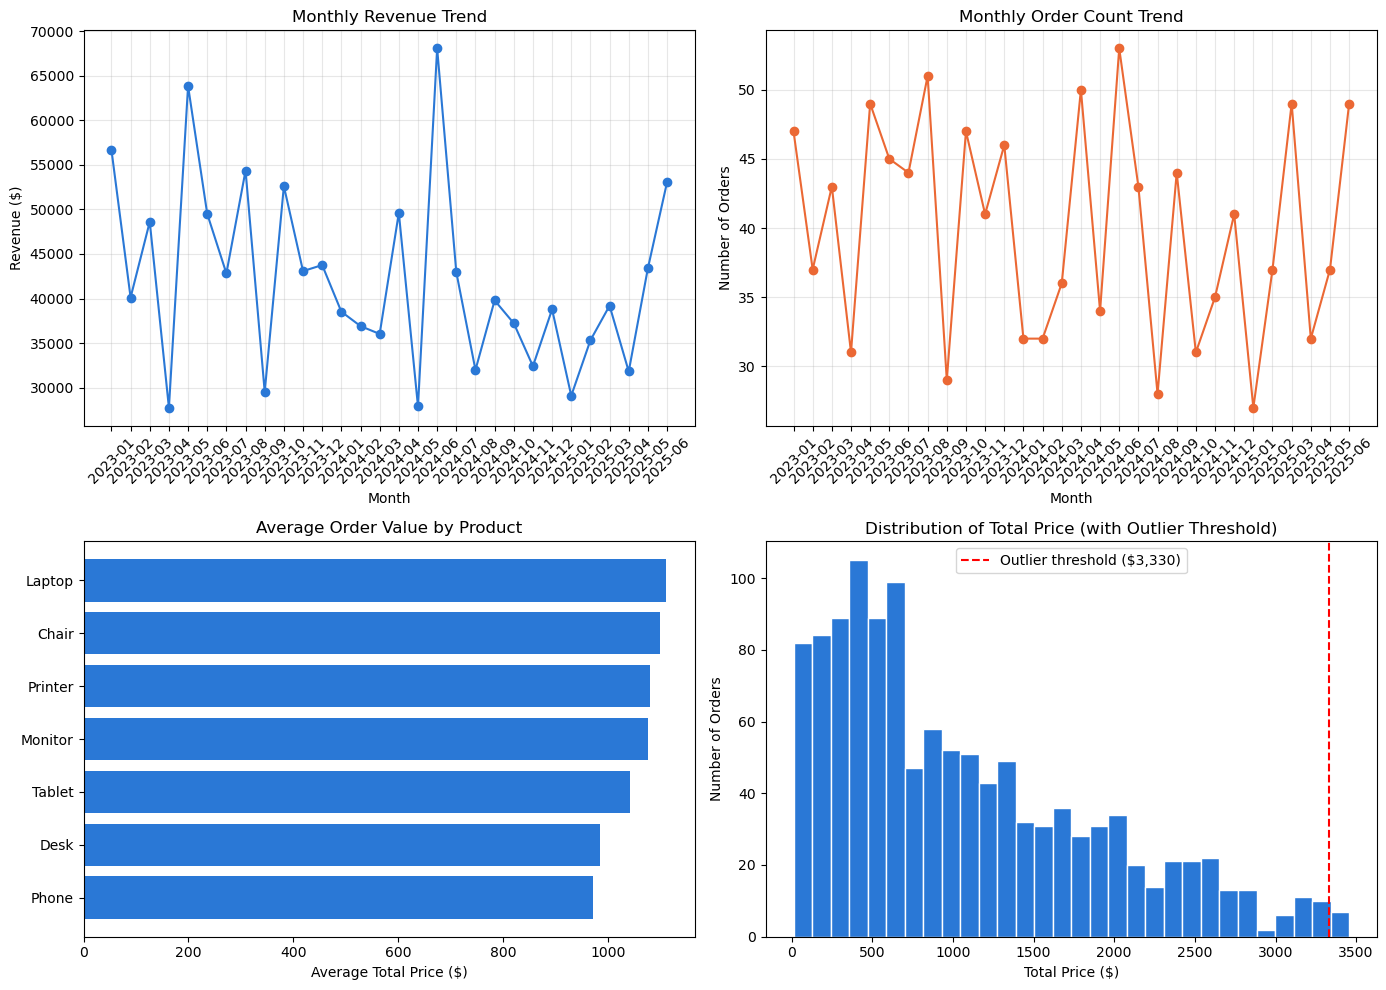


=== Outlier detection (IQR method) ===
Quantity: bounds=(-1.00, 7.00)  n_outliers=0
UnitPrice: bounds=(-317.20, 1024.83)  n_outliers=0
ItemsInCart: bounds=(-0.50, 11.50)  n_outliers=0
TotalPrice: bounds=(-1341.41, 3330.41)  n_outliers=8

TotalPrice outlier rows:
  OrderID Product  Quantity  UnitPrice  TotalPrice
ORD200107 Printer         5     670.75     3353.75
ORD200326  Laptop         5     670.48     3352.40
ORD200328  Tablet         5     674.04     3370.20
ORD200469   Chair         5     676.98     3384.90
ORD200632  Laptop         5     678.16     3390.80
ORD200789  Tablet         5     691.28     3456.40
ORD201065 Printer         5     666.80     3334.00
ORD201122 Monitor         5     678.19     3390.95

=== Summary of key observations ===
1. TotalPrice distribution is right-skewed (mean > median): mean=$1053.97, median=$823.62.
2. 8 total outlier rows detected across numeric columns (IQR method).
3. Revenue by year: 2023=$552,643.24, 2024=$480,235.87, 2025=$231,882.85
4. Hig

In [35]:
    df = load_and_inspect(r"C:\Users\user\Documents\data analytics daily challenge\Decodelabs\Cleaned_Dataset.xlsx")
    stats = basic_statistics(df)
    monthly, yearly = analyze_trends(df)
    plot_trends(df, monthly)
    outlier_summary = detect_outliers(df)
    summarize_observations(df, stats, monthly, yearly, outlier_summary)

Business Interpretation of Your Results
1. TotalPrice distribution is right-skewed (Mean = $1,053.97 > Median = $823.62)
What it means

Most customer orders are worth around $824, but a small number of very expensive orders increase the average to about $1,054.

Business implication
The company earns a significant portion of its revenue from a relatively small number of high-value orders.
Relying solely on the average order value could overestimate what a typical customer spends.
The median provides a better picture of a "typical" order.
Business recommendation
Create loyalty programs or premium offers to encourage more customers to place larger orders.
Segment customers into regular and high-value groups for targeted marketing.

2. Eight TotalPrice outliers were detected

The outliers are:

Product	Quantity	Unit Price	Total Price
Printer	5	670.75	3353.75
Laptop	5	670.48	3352.40
Tablet	5	674.04	3370.20
Chair	5	676.98	3384.90
Laptop	5	678.16	3390.80
Tablet	5	691.28	3456.40
Printer	5	666.80	3334.00
Monitor	5	678.19	3390.95
What it means

These are unusually expensive orders compared with the rest of the dataset.

Business implication

These could represent:

Bulk purchases by corporate customers.
High-value customers.
Promotional campaigns.
Data entry errors (which should be verified).

Since all quantities are 5, the pricing appears consistent, suggesting they are likely genuine large orders rather than mistakes.

Business recommendation
Review these customers to identify opportunities for repeat business.
Consider offering bulk-purchase discounts or dedicated account management if these are business clients.

3. Revenue by Year
Year	Revenue
2023	$552,643.24
2024	$480,235.87
2025	$231,882.85
What it means

Revenue decreases each year.

Business implication

This trend may indicate:

Falling sales demand.
Increased competition.
Loss of customers.
Reduced marketing effectiveness.
Or, if the 2025 data covers only part of the year, it may simply be incomplete.
Business recommendation
Confirm whether the 2025 dataset includes the full year before concluding that sales have declined.
If it is complete, investigate the causes of the downward trend and develop strategies to regain growth.

4. Laptop has the highest average order value
What it means

Orders containing laptops generate the highest average revenue.

Business implication

Laptops are the company's highest-value product.

Business recommendation
Prioritize laptop inventory to avoid stockouts.
Invest more in laptop marketing.
Bundle laptops with accessories such as mice, keyboards, or warranties to increase revenue further.

5. Cancelled orders have the highest average order value
What it means

The most valuable orders are also the ones most likely to be cancelled.

Business implication

This is potentially the most important finding. It suggests the company may be losing significant revenue from cancelled high-value purchases.

Possible reasons include:

Payment failures.
Stock shortages.
Delivery delays.
Customers changing their minds before fulfillment.
Fraud detection systems flagging expensive orders.
Business recommendation

The business should analyze why high-value orders are being cancelled and address the root causes. Reducing cancellations of these orders could have a substantial positive impact on revenue.

Overall Business Summary

Most customers place moderate-value orders, while a small number of expensive purchases contribute disproportionately to revenue.
The detected outliers are likely legitimate high-value transactions and may represent valuable customers.
Revenue appears to be declining over time, though the completeness of the 2025 data should be verified before drawing firm conclusions.
Laptops are the strongest revenue-generating product and deserve strategic focus.
High-value order cancellations are a critical issue because they represent lost revenue and should be investigated as a priority.
Conclusion

From a business perspective, the company should focus on:

Retaining and growing its high-value customer segment.
Increasing sales of high-value products like laptops.
Investigating and reducing cancellations of expensive orders.
